# Import

In [26]:
import pandas as pd
import numpy as np
import os
import io
import boto3
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import mlflow
import mlflow.sklearn

load_dotenv("../.env", override=True)

BUCKET  = os.getenv("S3_BUCKET")
PROC    = f"s3://{BUCKET}/processed"
STORAGE = {
    "key"           : os.getenv("AWS_ACCESS_KEY_ID"),
    "secret"        : os.getenv("AWS_SECRET_ACCESS_KEY"),
    "client_kwargs" : {"region_name": os.getenv("AWS_REGION")}
}

print(" Imports OK")

 Imports OK


# Chargement des données

In [27]:
df = pd.read_csv(f"{PROC}/dataset_features.csv", storage_options=STORAGE)

FEATURES = [
    "rank_dif",
    "goals_dif", "goals_dif_l5",
    "goals_suf_dif", "goals_suf_dif_l5",
    "goals_per_ranking_dif",
    "dif_rank_agst", "dif_rank_agst_l5",
    "dif_points_rank", "dif_points_rank_l5",
    "is_friendly"
]

X = df[FEATURES]
y = df["target"]

print(f"Dataset : {X.shape[0]} matchs · {X.shape[1]} features")
print(f"   Classes : {y.value_counts().to_dict()}")

Dataset : 3019 matchs · 11 features
   Classes : {1: 1625, 0: 1394}


# Train/test split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"Split effectué")
print(f"   Train : {len(X_train)} matchs")
print(f"   Test  : {len(X_test)} matchs")

Split effectué
   Train : 2415 matchs
   Test  : 604 matchs


# Connexion MLflow

In [29]:
load_dotenv("../.env", override=True)

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))
mlflow.set_experiment(os.getenv("MLFLOW_EXPERIMENT_NAME"))

print(f" MLflow configuré")
print(f"   URI : {os.getenv('MLFLOW_TRACKING_URI')}")

 MLflow configuré
   URI : https://remiince-mlflow-server.hf.space


# GradientBoosting + GridSearchCV

In [30]:
with mlflow.start_run(run_name="gradient_boosting"):

    # GridSearchCV
    gb_params = {
        "learning_rate"    : [0.01, 0.1, 0.5],
        "min_samples_split": [5, 10],
        "min_samples_leaf" : [3, 5],
        "max_depth"        : [3, 5, 10],
        "max_features"     : ["sqrt"],
        "n_estimators"     : [100, 200]
    }
    gb_cv = GridSearchCV(
        GradientBoostingClassifier(random_state=5),
        gb_params, cv=3, n_jobs=-1, scoring="roc_auc"
    )
    gb_cv.fit(X_train, y_train)
    gb = gb_cv.best_estimator_

    auc_train = roc_auc_score(y_train, gb.predict_proba(X_train)[:, 1])
    auc_test  = roc_auc_score(y_test,  gb.predict_proba(X_test)[:, 1])
    acc_test  = accuracy_score(y_test, gb.predict(X_test))

    mlflow.log_params(gb_cv.best_params_)
    mlflow.log_metric("auc_train",     round(auc_train, 4))
    mlflow.log_metric("auc_test",      round(auc_test, 4))
    mlflow.log_metric("test_accuracy", round(acc_test, 4))

    print(f"GradientBoosting : AUC {auc_test:.3f} · Accuracy {acc_test:.3f}")
    print(f"   Meilleurs params : {gb_cv.best_params_}")

GradientBoosting : AUC 0.774 · Accuracy 0.699
   Meilleurs params : {'learning_rate': 0.01, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
🏃 View run gradient_boosting at: https://remiince-mlflow-server.hf.space/#/experiments/1/runs/a10dca6d41bd46e4a0b2d3f902c9479f
🧪 View experiment at: https://remiince-mlflow-server.hf.space/#/experiments/1


# Visualisations

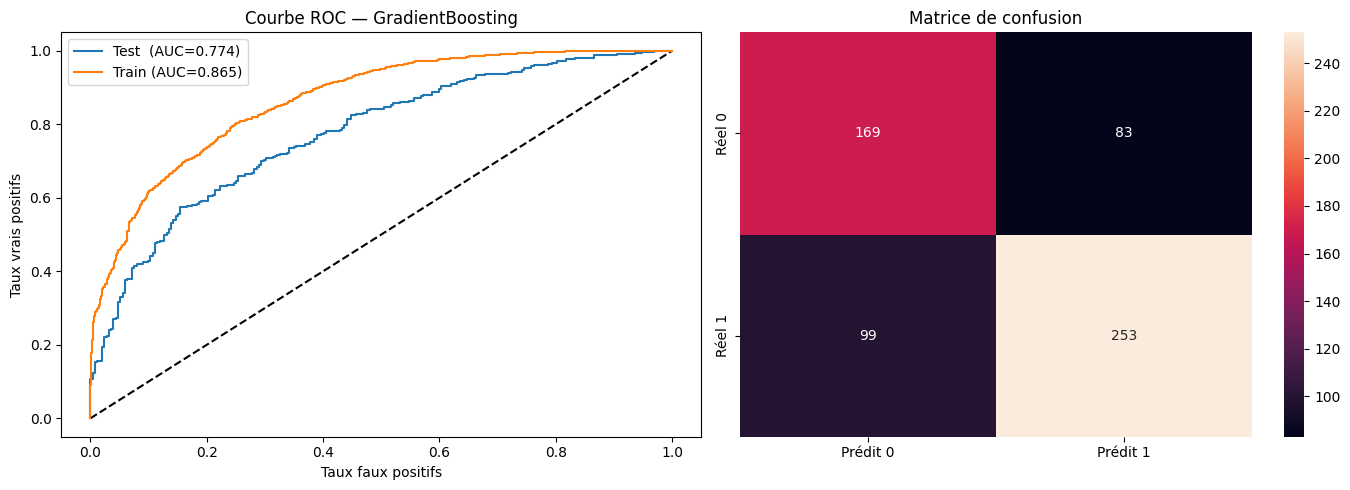

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC
fpr_test,  tpr_test,  _ = roc_curve(y_test,  gb.predict_proba(X_test)[:, 1])
fpr_train, tpr_train, _ = roc_curve(y_train, gb.predict_proba(X_train)[:, 1])

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].plot(fpr_test,  tpr_test,  label=f"Test  (AUC={auc_test:.3f})")
axes[0].plot(fpr_train, tpr_train, label=f"Train (AUC={auc_train:.3f})")
axes[0].set_title("Courbe ROC — GradientBoosting")
axes[0].set_xlabel("Taux faux positifs")
axes[0].set_ylabel("Taux vrais positifs")
axes[0].legend()

# Matrice de confusion
cm = confusion_matrix(y_test, gb.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", ax=axes[1],
            xticklabels=["Prédit 0", "Prédit 1"],
            yticklabels=["Réel 0", "Réel 1"])
axes[1].set_title("Matrice de confusion")

plt.tight_layout()
plt.show()

# Importance des features

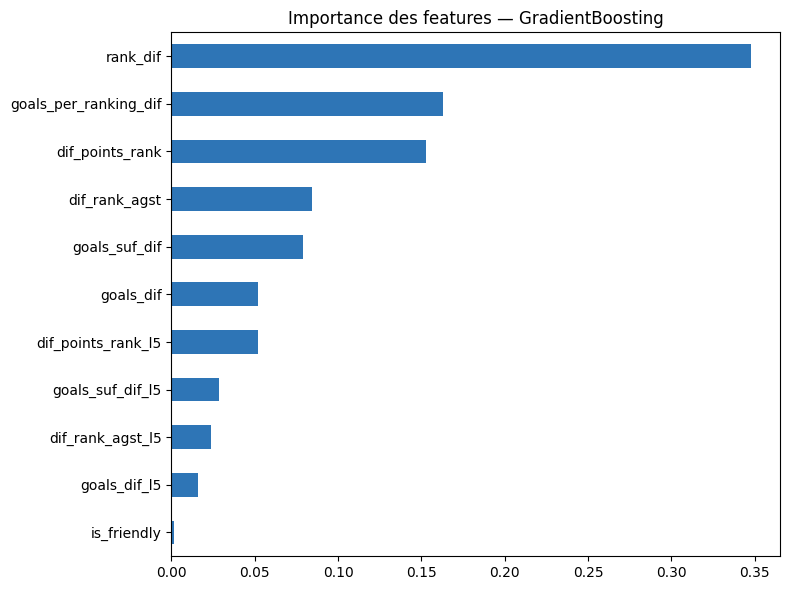

In [32]:
importances = pd.Series(
    gb.feature_importances_, index=FEATURES
).sort_values(ascending=True)

importances.plot(kind="barh", figsize=(8, 6), color="#2E75B6")
plt.title("Importance des features — GradientBoosting")
plt.tight_layout()
plt.show()

# Logistic Regression

In [33]:
with mlflow.start_run(run_name="logistic_regression"):
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)
    model_lr = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
    model_lr.fit(X_tr_sc, y_train)
    auc_lr  = roc_auc_score(y_test, model_lr.predict_proba(X_te_sc)[:, 1])
    acc_lr  = accuracy_score(y_test, model_lr.predict(X_te_sc))
    mlflow.log_params({"C": 1.0, "max_iter": 1000})
    mlflow.log_metric("auc_test",      round(auc_lr, 4))
    mlflow.log_metric("test_accuracy", round(acc_lr, 4))
    print(f"Logistic Regression : AUC {auc_lr:.3f} · Accuracy {acc_lr:.3f}")


Logistic Regression : AUC 0.776 · Accuracy 0.699
🏃 View run logistic_regression at: https://remiince-mlflow-server.hf.space/#/experiments/1/runs/f3743e4053084789a401903214616e6a
🧪 View experiment at: https://remiince-mlflow-server.hf.space/#/experiments/1


# Random Forest

In [34]:
with mlflow.start_run(run_name="random_forest"):
    model_rf = RandomForestClassifier(n_estimators=250, max_depth=20, random_state=1)
    model_rf.fit(X_train, y_train)
    auc_rf  = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:, 1])
    acc_rf  = accuracy_score(y_test, model_rf.predict(X_test))
    mlflow.log_params({"n_estimators": 250, "max_depth": 20})
    mlflow.log_metric("auc_test",      round(auc_rf, 4))
    mlflow.log_metric("test_accuracy", round(acc_rf, 4))
    print(f"Random Forest : AUC {auc_rf:.3f} · Accuracy {acc_rf:.3f}")


Random Forest : AUC 0.755 · Accuracy 0.680
🏃 View run random_forest at: https://remiince-mlflow-server.hf.space/#/experiments/1/runs/6bebdbe356064615b94a5945f7f3482f
🧪 View experiment at: https://remiince-mlflow-server.hf.space/#/experiments/1


# XGBoost

In [35]:
with mlflow.start_run(run_name="xgboost"):
    model_xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
    model_xgb.fit(X_train, y_train)
    auc_xgb = roc_auc_score(y_test, model_xgb.predict_proba(X_test)[:, 1])
    acc_xgb = accuracy_score(y_test, model_xgb.predict(X_test))
    mlflow.log_params({"n_estimators": 200, "max_depth": 4, "learning_rate": 0.1})
    mlflow.log_metric("auc_test",      round(auc_xgb, 4))
    mlflow.log_metric("test_accuracy", round(acc_xgb, 4))
    print(f"XGBoost : AUC {auc_xgb:.3f} · Accuracy {acc_xgb:.3f}")

XGBoost : AUC 0.752 · Accuracy 0.684
🏃 View run xgboost at: https://remiince-mlflow-server.hf.space/#/experiments/1/runs/9cc3d7f5077e4677a66632ff0e3833dc
🧪 View experiment at: https://remiince-mlflow-server.hf.space/#/experiments/1


# Sauvegarde dans le S3

In [36]:
def save_model_s3(model, key):
    s3 = boto3.client('s3',
        aws_access_key_id     = os.getenv('AWS_ACCESS_KEY_ID'),
        aws_secret_access_key = os.getenv('AWS_SECRET_ACCESS_KEY'),
        region_name           = os.getenv('AWS_REGION'))
    buf = io.BytesIO()
    joblib.dump(model, buf)
    buf.seek(0)
    s3.put_object(Bucket=BUCKET, Key=key, Body=buf.getvalue())
    print(f"Sauvegardé dans s3://{BUCKET}/{key}")

save_model_s3(gb, "models/gradient_boosting.pkl")
print("Gradient Boosting sauvegardé sur S3")

Sauvegardé dans s3://fifa-wc-predict-915328198414-eu-west-3-an/models/gradient_boosting.pkl
Gradient Boosting sauvegardé sur S3


In [37]:
print(model_rf)
print(model_lr)
print(model_xgb)

RandomForestClassifier(max_depth=20, n_estimators=250, random_state=1)
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


In [38]:
save_model_s3(model_rf,  "models/random_forest.pkl")
save_model_s3(model_lr,  "models/logistic_regression.pkl")
save_model_s3(model_xgb, "models/xgboost.pkl")
print(" Tous les modèles mis à jour sur S3")

Sauvegardé dans s3://fifa-wc-predict-915328198414-eu-west-3-an/models/random_forest.pkl
Sauvegardé dans s3://fifa-wc-predict-915328198414-eu-west-3-an/models/logistic_regression.pkl
Sauvegardé dans s3://fifa-wc-predict-915328198414-eu-west-3-an/models/xgboost.pkl
 Tous les modèles mis à jour sur S3


In [39]:
print(f"Random Forest features : {model_rf.n_features_in_}")

Random Forest features : 11


In [40]:
# Dans le notebook — vérifier le modèle sur S3
import boto3, io, joblib, os
from dotenv import load_dotenv

load_dotenv("../.env", override=True)
BUCKET = os.getenv("S3_BUCKET")

s3  = boto3.client('s3',
    aws_access_key_id     = os.getenv('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key = os.getenv('AWS_SECRET_ACCESS_KEY'),
    region_name           = os.getenv('AWS_REGION'))

obj = s3.get_object(Bucket=BUCKET, Key="models/random_forest.pkl")
rf_s3 = joblib.load(io.BytesIO(obj['Body'].read()))
print(f"Random Forest sur S3 : {rf_s3.n_features_in_} features")

Random Forest sur S3 : 11 features


In [41]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = gb.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65       252
           1       0.75      0.72      0.74       352

    accuracy                           0.70       604
   macro avg       0.69      0.69      0.69       604
weighted avg       0.70      0.70      0.70       604

[[169  83]
 [ 99 253]]
